In [ ]:
import os

import cmcrameri as cmc  # noqa: F401
import matplotlib as mpl
import matplotlib.pyplot as plt
import metpy  # noqa: F401
import numpy as np
import xarray as xr
import yaml
from unseen_awg.weather_generator import WeatherGenerator

In [7]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

mpl.rc_file("../../matplotlibrc")

In [8]:
rng = np.random.default_rng(0)
k = 8
minimum_timedelta_days = 180

state_re = xr.Dataset(
    {"year": 2023, "dayofyear": 248, "sample": 13, "ensemble_member": 0}
)
state_era5 = xr.Dataset(
    {"year": 2023, "dayofyear": 248, "sample": 0, "ensemble_member": 0}
)

In [9]:
wg_reforecasts = WeatherGenerator.load(
    os.path.join(paths["dir_wgs"], "wg_reforecasts_5e06172f_f40e9460_1e69bda9")
)
wg_era5 = WeatherGenerator.load(
    os.path.join(paths["dir_wgs"], "wg_era5_f3d1f2f7_6e629cd9_7560715e")
)

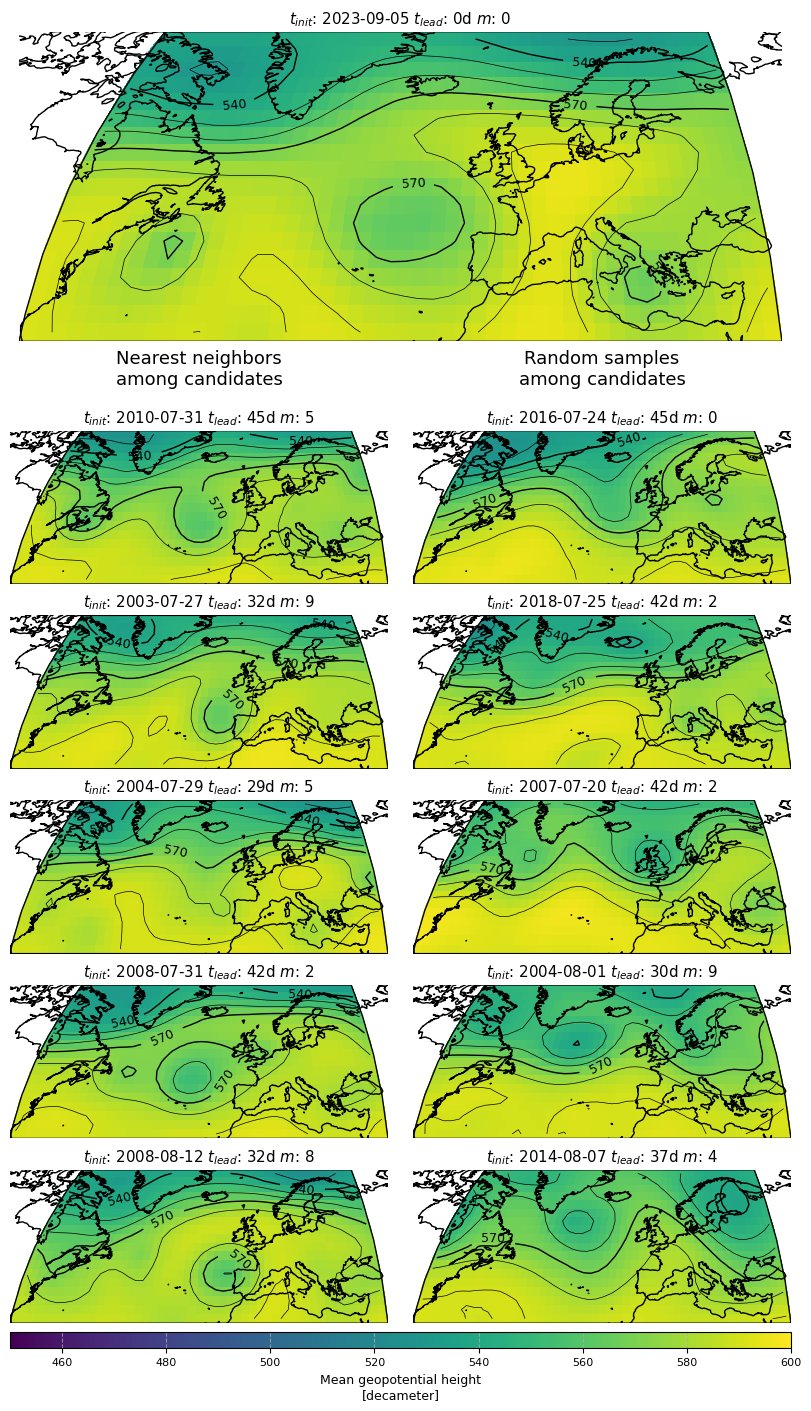

In [10]:
fig = wg_reforecasts.plot_k_nearest_and_random_neighbors(
    state=state_re,
    k=5,
    rng=rng,
    minimum_timedelta_days=180,
)

plt.savefig(os.path.join(paths["dir_images"], "patterns_neigbors.png"))

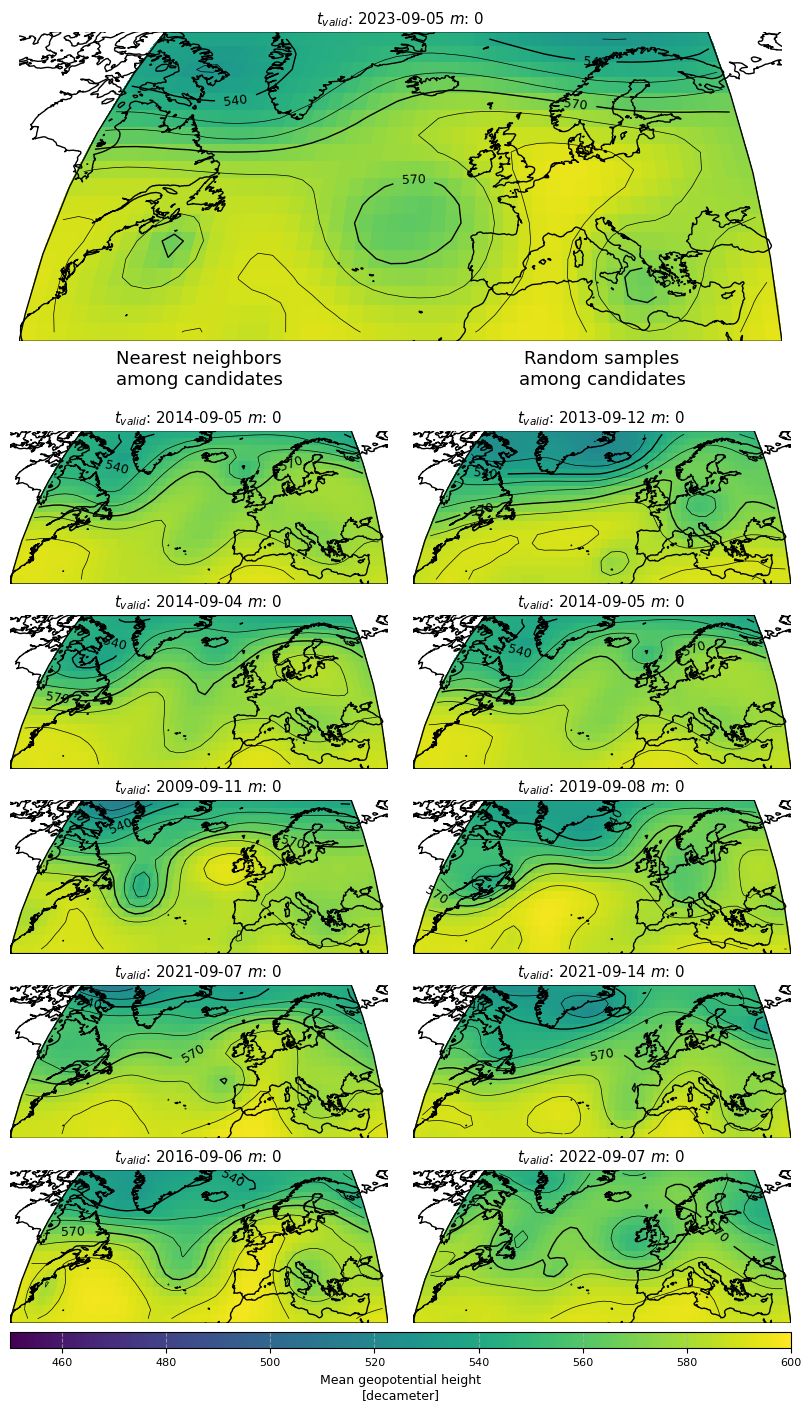

In [11]:
fig = wg_era5.plot_k_nearest_and_random_neighbors(
    state=state_era5,
    k=5,
    rng=rng,
    minimum_timedelta_days=180,
)

plt.savefig(os.path.join(paths["dir_images"], "patterns_neigbors_era_wg.png"))